In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
# Catalog of all objects from all the different combinations (single exposures, deep coadds, etc.)
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/cascades/3.1/LRG/alltiles_LRGzinfo.fits'))
print(len(zbest))

1083682


In [4]:
# Select deep coadds
mask = zbest['subset']=='deep'
print(np.sum(mask))

# Select QSO+LRG tiles
mask &= zbest['TARGETS']=='QSO+LRG'
print(np.sum(mask))

zbest = zbest[mask]

print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

58113
34868
34868
34702


In [5]:
# # Print summary of the tiles
# t = Table()
# t['TILEID'], t['count'] = np.unique(zbest['TILEID'], return_counts=True)
# t['efftime'] = 0
# t['n_exp'] = 0
# for index, tileid in enumerate(t['TILEID']):
#     mask = zbest['TILEID']==tileid
#     t['n_exp'][index] = np.max(zbest['COADD_NUMEXP'][mask])
#     t['efftime'][index] = np.max(zbest['EFFTIME_DARK'][mask])
# t

In [6]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Require a minimum depth for the deep coadd
min_depth = 4000.
mask = zbest['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

print(len(zbest))

FIBERSTATUS 29372 5496 0.1576230354479752
No data 29370 2 6.809206046574969e-05
Min depth 18686 10684 0.636227442969016
18686


In [7]:
# Ting-Wen's quality cuts
mask = zbest['DELTACHI2']>20
mask &= zbest['Z']<1.4

mask &= zbest['ZWARN']==0
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]
print(len(zbest))

Quality cuts 18202 484 0.9740982553783581
18202


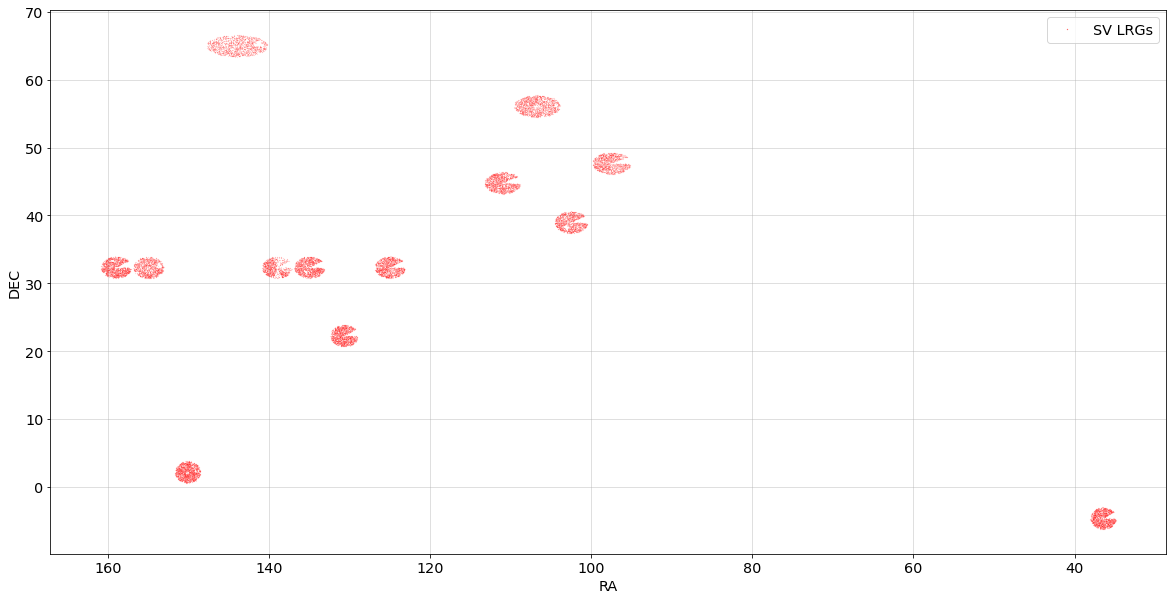

In [8]:
plt.figure(figsize=(20, 10))
plt.plot(zbest['TARGET_RA'], zbest['TARGET_DEC'], 'r.', ms=.1, label='SV LRGs')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

__Add Galactic extinction columns from sweep catalogs (it might take a minute or two)__

In [9]:
ls_columns = ['MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2']

# Snippets taken from desitarget

from desitarget.targets import encode_targetid

def decode_sweep_name(sweepname):
    sweepname = os.path.basename(sweepname)

    ramin, ramax = float(sweepname[6:9]), float(sweepname[14:17])
    decmin, decmax = float(sweepname[10:13]), float(sweepname[18:21])

    if sweepname[9] == 'm':
        decmin *= -1
    if sweepname[17] == 'm':
        decmax *= -1

    return [ramin, ramax, decmin, decmax]

def is_in_box(objs, radecbox, ra_col='RA', dec_col='DEC'):

    ramin, ramax, decmin, decmax = radecbox

    # ADM check for some common mistakes.
    if decmin < -90. or decmax > 90. or decmax <= decmin or ramax <= ramin:
        msg = "Strange input: [ramin, ramax, decmin, decmax] = {}".format(radecbox)
        log.critical(msg)
        raise ValueError(msg)

    ii = ((objs[ra_col] >= ramin) & (objs[ra_col] < ramax)
          & (objs[dec_col] >= decmin) & (objs[dec_col] < decmax))

    return ii

# Ignore any possible north/south overlap

sweep_fn_list = []
for field in ['north', 'south']:
    sweep_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/sweep/9.0'.format(field)
    sweep_fn_list += sorted(glob.glob(os.path.join(sweep_dir, '*.fits')))
sweep_fn_list = np.array(sweep_fn_list)

sweep_radec_list = [decode_sweep_name(sweep_fn) for sweep_fn in sweep_fn_list]
mask = np.array([np.any(is_in_box(zbest, sweep_radec, ra_col='TARGET_RA', dec_col='TARGET_DEC')) for sweep_radec in sweep_radec_list])
print(np.sum(mask))
sweep_fn_list = sweep_fn_list[mask]

ls_stack = []
for sweep_fn in sweep_fn_list:
    ls = Table(fitsio.read(sweep_fn, columns=['OBJID', 'BRICKID', 'RELEASE']))
    targetid = encode_targetid(ls['OBJID'], ls['BRICKID'], ls['RELEASE'])
    idx = np.where(np.in1d(targetid, zbest['TARGETID']))[0]
    if len(idx)==0:
        continue
    targetid = targetid[idx]
    ls = Table(fitsio.read(sweep_fn, rows=idx, columns=ls_columns))
    ls['TARGETID'] = targetid
    # if '/south/sweep/' in sweep_fn:
    #     ls['field'] = 'south'
    # else:
    #     ls['field'] = 'north'
    # pz_fn = sweep_fn.replace('sweep/9.0/', 'sweep/9.0-photo-z/').replace('.fits', '-pz.fits')
    # pz = Table(fitsio.read(pz_fn, rows=idx))
    # pz.remove_columns(['OBJID', 'BRICKID', 'RELEASE'])
    # ls = hstack([ls, pz])
    ls_stack.append(ls)
ls = vstack(ls_stack)
print(len(zbest), len(ls))

zbest = join(zbest, ls, keys='TARGETID')

31
18202 18202


In [10]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']/zbest['MW_TRANSMISSION_Z'])
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']/zbest['MW_TRANSMISSION_W1'])
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']/zbest['MW_TRANSMISSION_W2'])
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']/zbest['MW_TRANSMISSION_Z'])

In [11]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = (zbest['SV1_DESI_TARGET'] & 2**0>0)
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print()

sv_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(sv_qso & lrg_sv), '{:.2f}%'.format(np.sum(sv_qso & lrg_sv)/np.sum(lrg_sv)*100))
print(np.sum(sv_qso & lrg_opt), '{:.2f}%'.format(np.sum(sv_qso & lrg_opt)/np.sum(lrg_opt)*100))
print(np.sum(sv_qso & lrg_ir), '{:.2f}%'.format(np.sum(sv_qso & lrg_ir)/np.sum(lrg_ir)*100))

4839
5124
18202

422 2.32%
38 0.79%
176 3.43%


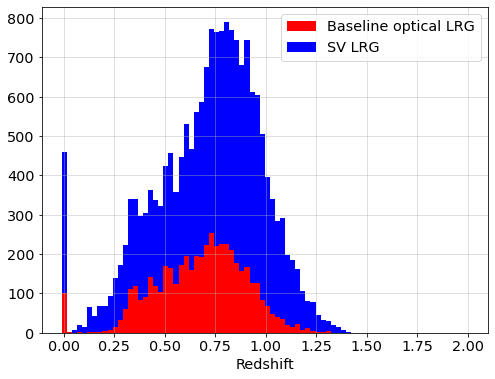

In [12]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt], bins=80, range=(-0.01, 2.0), color='red', label='Baseline optical LRG', zorder=1)
plt.hist(zbest['Z'][lrg_sv], bins=80, range=(-0.01, 2.0), color='blue', label='SV LRG', zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

In [13]:
mask_gal = zbest['SPECTYPE']=='GALAXY'
mask_star = (zbest['SPECTYPE']=='STAR') | (zbest['Z']<0.0003)
mask_qso = zbest['SPECTYPE']=='QSO'

# Force the very low-z objects to have SPECTYPE=STAR
zbest['SPECTYPE'][mask_star] = 'STAR'

Lowest non-STAR redshift: 0.002555975549533229


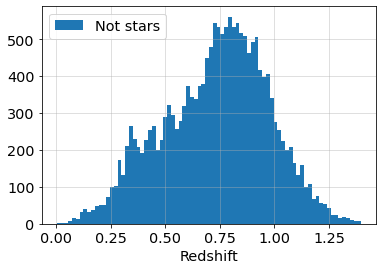

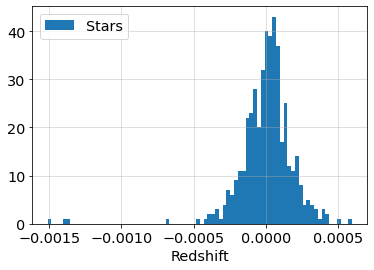

In [14]:
print('Lowest non-STAR redshift: {:}'.format(zbest['Z'][~mask_star].min()))

plt.hist(zbest['Z'][~mask_star], bins=80, label='Not stars')
plt.xlabel('Redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

plt.hist(zbest['Z'][mask_star], bins=80, label='Stars')
plt.xlabel('Redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

SV LRG
457 0.02510713108449621


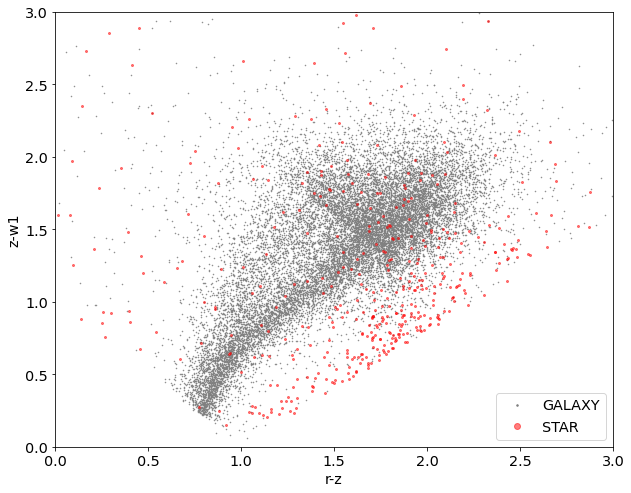

369 0.020753655793025873


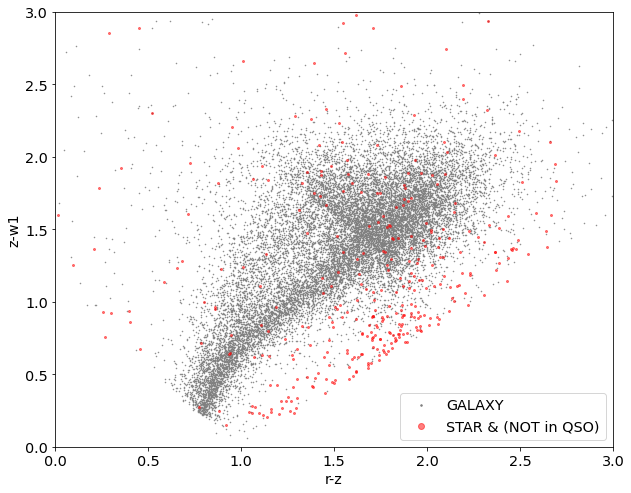

In [15]:
print('SV LRG')
print(np.sum(mask_star), np.sum(mask_star)/len(zbest))
plt.figure(figsize=(10, 8))
plt.plot((zbest['rmag']-zbest['zmag'])[mask_gal], (zbest['zmag']-zbest['w1mag'])[mask_gal], '.', color='0.5', ms=1, label='GALAXY')
plt.plot((zbest['rmag']-zbest['zmag'])[mask_star],( zbest['zmag']-zbest['w1mag'])[mask_star], 'r.', ms=4, label='STAR', alpha=0.5)
plt.xlabel('r-z')
plt.ylabel('z-w1')
plt.axis([0, 3, 0, 3])
plt.legend(markerscale=3)
plt.legend(markerscale=3, loc='lower right')
plt.show()

mask1 = mask_star & (~sv_qso)
print(np.sum(mask1), np.sum(mask1)/np.sum(~sv_qso))
plt.figure(figsize=(10, 8))
plt.plot((zbest['rmag']-zbest['zmag'])[mask_gal], (zbest['zmag']-zbest['w1mag'])[mask_gal], '.', color='0.5', ms=1, label='GALAXY')
plt.plot((zbest['rmag']-zbest['zmag'])[mask1],( zbest['zmag']-zbest['w1mag'])[mask1], 'r.', ms=4, label='STAR & (NOT in QSO)', alpha=0.5)
plt.xlabel('r-z')
plt.ylabel('z-w1')
plt.axis([0, 3, 0, 3])
plt.legend(markerscale=3, loc='lower right')
plt.show()

In [16]:
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

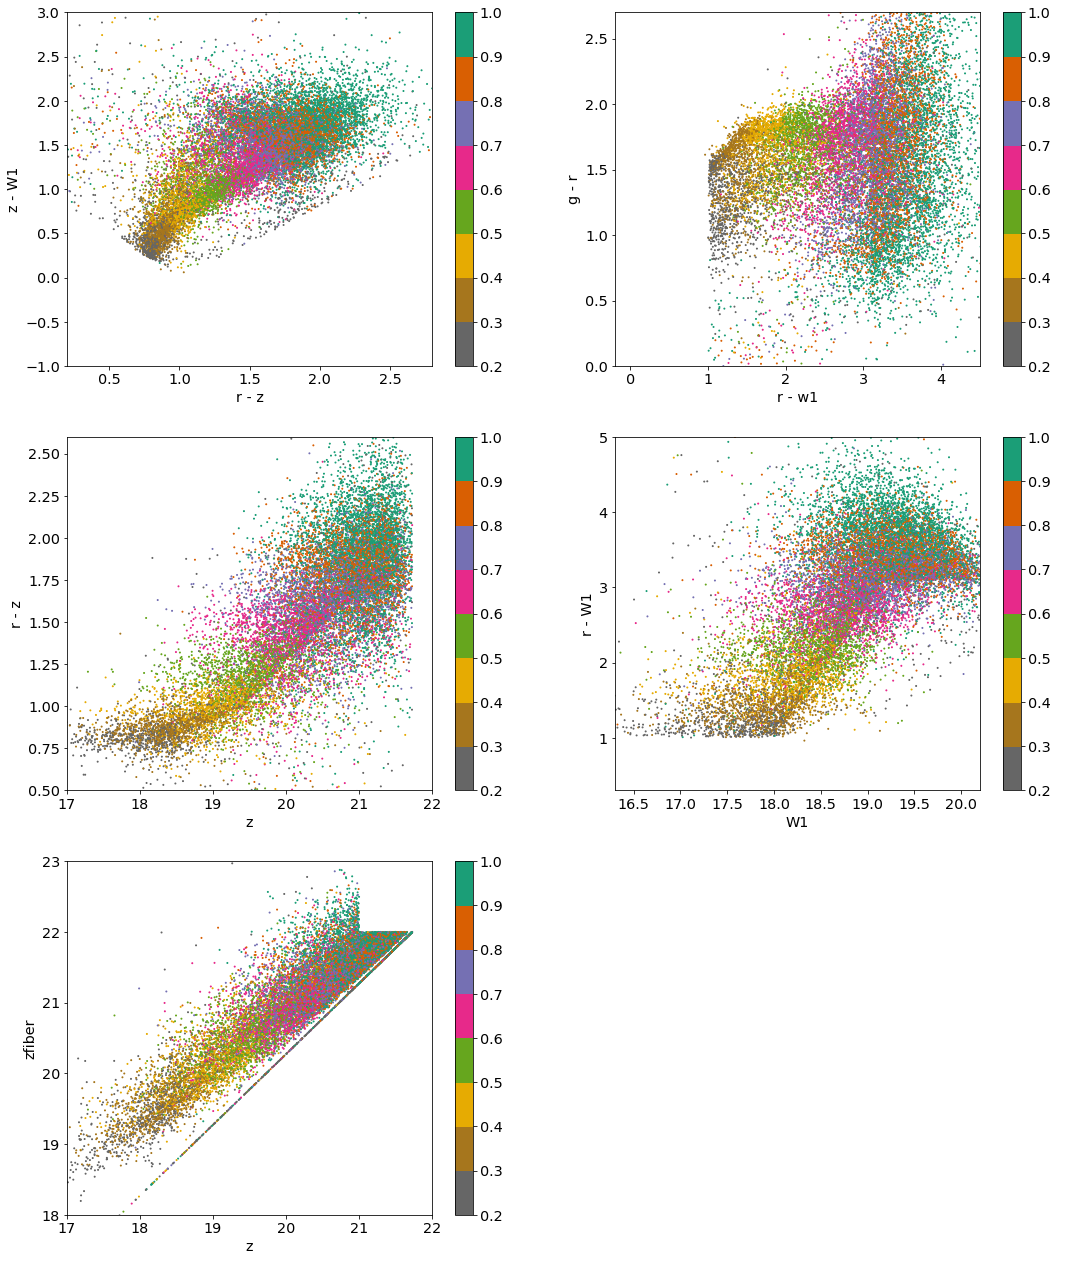

In [17]:
lrg_plot.color_plot_3x2_simple(zbest, color_col='Z', ms=1)

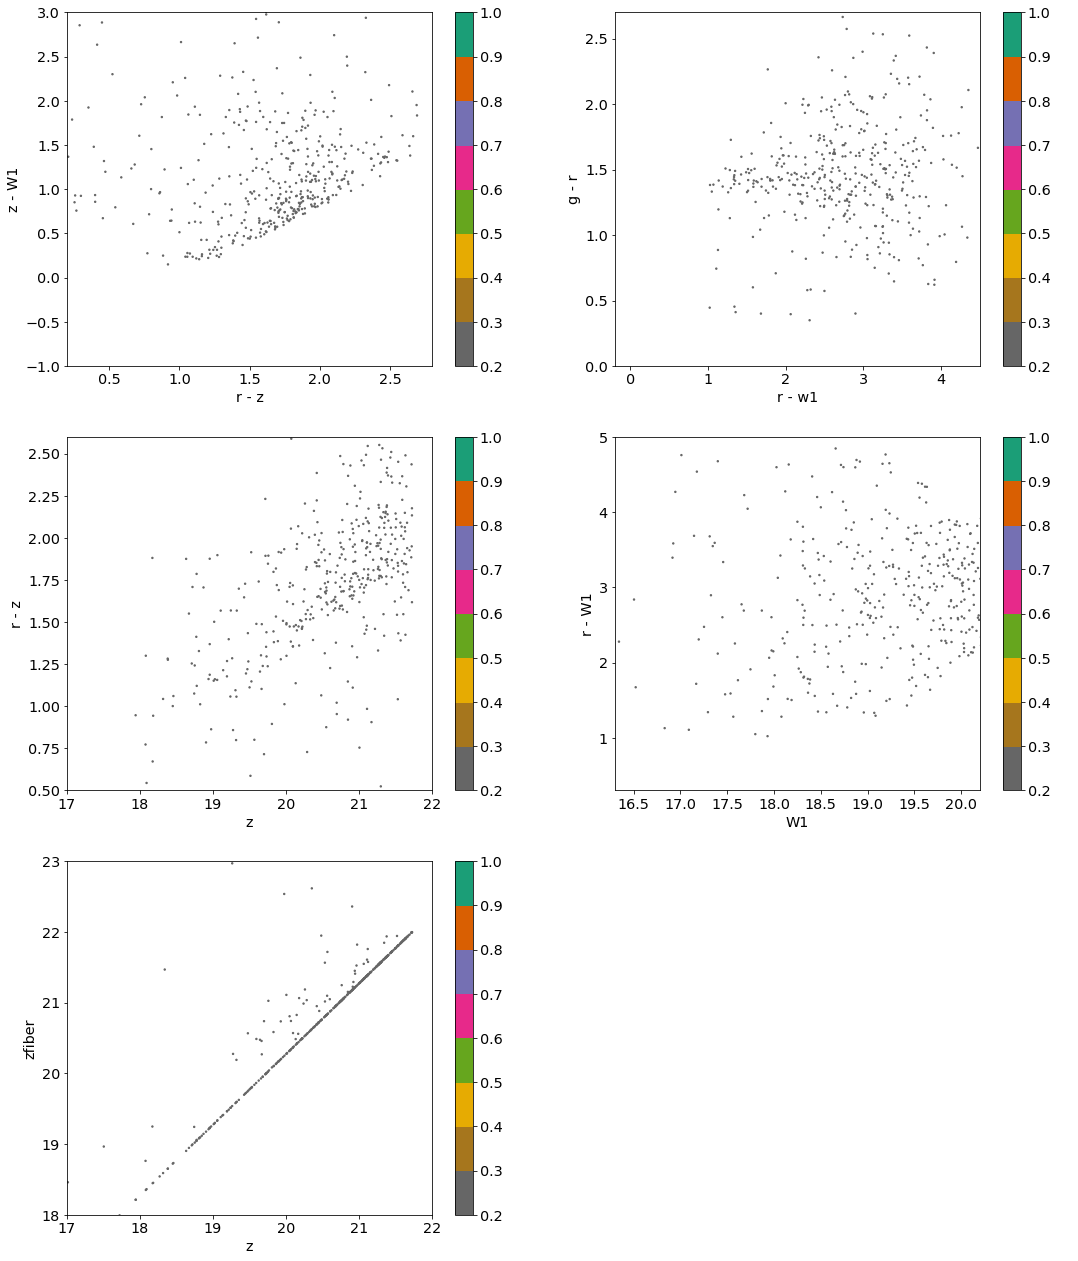

In [18]:
lrg_plot.color_plot_3x2_simple(zbest[mask_star], color_col='Z', ms=2)

In [19]:
print('Stars in LRG_SV: {:.1f}% ({}/{})'.format(np.sum(mask_star & lrg_sv)/np.sum(lrg_sv)*100, np.sum(mask_star & lrg_sv), np.sum(lrg_sv)))
print('Stars in LRG_OPT: {:.1f}% ({}/{})'.format(np.sum(mask_star & lrg_opt)/np.sum(lrg_opt)*100, np.sum(mask_star & lrg_opt), np.sum(lrg_opt)))
print('Stars in LRG_IR: {:.1f}% ({}/{})'.format(np.sum(mask_star & lrg_ir)/np.sum(lrg_ir)*100, np.sum(mask_star & lrg_ir), np.sum(lrg_ir)))

Stars in LRG_SV: 2.5% (457/18202)
Stars in LRG_OPT: 2.1% (102/4839)
Stars in LRG_IR: 2.0% (103/5124)


In [20]:
print('Excluding QSO targets:')
print('Stars in LRG_SV: {:.1f}% ({}/{})'.format(np.sum((~sv_qso) & mask_star & lrg_sv)/np.sum(lrg_sv & (~sv_qso))*100, np.sum((~sv_qso) & mask_star & lrg_sv), np.sum(lrg_sv & (~sv_qso))))
print('Stars in LRG_OPT: {:.1f}% ({}/{})'.format(np.sum((~sv_qso) & mask_star & lrg_opt)/np.sum(lrg_opt & (~sv_qso))*100, np.sum((~sv_qso) & mask_star & lrg_opt), np.sum(lrg_opt & (~sv_qso))))
print('Stars in LRG_IR: {:.1f}% ({}/{})'.format(np.sum((~sv_qso) & mask_star & lrg_ir)/np.sum(lrg_ir & (~sv_qso))*100, np.sum((~sv_qso) & mask_star & lrg_ir), np.sum(lrg_ir & (~sv_qso))))

Excluding QSO targets:
Stars in LRG_SV: 2.1% (369/17780)
Stars in LRG_OPT: 1.7% (84/4801)
Stars in LRG_IR: 1.6% (81/4948)


In [21]:
print('Only QSO targets:')
print('Stars in LRG_SV: {:.1f}% ({}/{})'.format(np.sum((sv_qso) & mask_star & lrg_sv)/np.sum(lrg_sv & (sv_qso))*100, np.sum((sv_qso) & mask_star & lrg_sv), np.sum(lrg_sv & (sv_qso))))
print('Stars in LRG_OPT: {:.1f}% ({}/{})'.format(np.sum((sv_qso) & mask_star & lrg_opt)/np.sum(lrg_opt & (sv_qso))*100, np.sum((sv_qso) & mask_star & lrg_opt), np.sum(lrg_opt & (sv_qso))))
print('Stars in LRG_IR: {:.1f}% ({}/{})'.format(np.sum((sv_qso) & mask_star & lrg_ir)/np.sum(lrg_ir & (sv_qso))*100, np.sum((sv_qso) & mask_star & lrg_ir), np.sum(lrg_ir & (sv_qso))))

Only QSO targets:
Stars in LRG_SV: 20.9% (88/422)
Stars in LRG_OPT: 47.4% (18/38)
Stars in LRG_IR: 12.5% (22/176)


-----
## SPECTYPE of PSF objects

In [22]:
print("All PSF objects in LRG_SV")
mask = zbest['MORPHTYPE']=='PSF'
t = Table()
t['type'], t['count'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

All PSF objects in LRG_SV


type,count,frac (%)
str6,int64,float64
QSO,169,12.6
STAR,397,29.7
GALAXY,772,57.7


In [23]:
print("All PSF objects in LRG_OPT")
mask = zbest['MORPHTYPE']=='PSF'
mask &= lrg_opt
t = Table()
t['type'], t['count'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

All PSF objects in LRG_OPT


type,count,frac (%)
str6,int64,float64
QSO,6,4.3
GALAXY,48,34.3
STAR,86,61.4


In [24]:
print("All PSF objects in LRG_ir")
mask = zbest['MORPHTYPE']=='PSF'
mask &= lrg_ir
t = Table()
t['type'], t['count'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

All PSF objects in LRG_ir


type,count,frac (%)
str6,int64,float64
GALAXY,58,24.1
QSO,88,36.5
STAR,95,39.4


-----
## MORPHTYPE of stars

In [25]:
print("All stars in LRG_SV")
mask = mask_star.copy()
t = Table()
t['type'], t['count'] = np.unique(zbest['MORPHTYPE'][mask], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

All stars in LRG_SV


type,count,frac (%)
str4,int64,float64
SER,9,2.0
REX,14,3.1
EXP,16,3.5
DEV,21,4.6
PSF,397,86.9


In [26]:
print("All stars in LRG_OPT")
mask = mask_star.copy()
mask &= lrg_opt
t = Table()
t['type'], t['count'] = np.unique(zbest['MORPHTYPE'][mask], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

All stars in LRG_OPT


type,count,frac (%)
str4,int64,float64
REX,1,1.0
SER,1,1.0
EXP,3,2.9
DEV,11,10.8
PSF,86,84.3


In [27]:
print("All stars in LRG_IR")
mask = mask_star.copy()
mask &= lrg_ir
t = Table()
t['type'], t['count'] = np.unique(zbest['MORPHTYPE'][mask], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

All stars in LRG_IR


type,count,frac (%)
str4,int64,float64
EXP,1,1.0
SER,2,1.9
DEV,5,4.9
PSF,95,92.2


------------
## Per-tile stellar contamination

In [28]:
print('LRG_OPT')
mask = mask_star & lrg_opt
print('Overall stellar contamination rate: {:.1f}%'.format(np.sum(mask)/np.sum(lrg_opt)*100))

t = Table()
t['tileid'], t['counts'] = np.unique(zbest['TILEID'][lrg_opt], return_counts=True)
t1 = Table()
t1['tileid'], t1['counts_star'] = np.unique(zbest['TILEID'][mask], return_counts=True)
t = join(t, t1)
t['star frac (%)'] = t['counts_star']/t['counts']*100
t['star frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_OPT
Overall stellar contamination rate: 2.1%


tileid,counts,counts_star,star frac (%)
int64,int64,int64,float64
80605,413,2,0.5
80607,440,18,4.1
80620,363,4,1.1
80622,323,1,0.3
80676,321,18,5.6
80678,332,24,7.2
80680,390,19,4.9
80682,382,8,2.1
80688,397,1,0.3


In [29]:
print('LRG_IR')
mask = mask_star & lrg_ir
print('Overall stellar contamination rate: {:.1f}%'.format(np.sum(mask)/np.sum(lrg_ir)*100))

t = Table()
t['tileid'], t['counts'] = np.unique(zbest['TILEID'][lrg_ir], return_counts=True)
t1 = Table()
t1['tileid'], t1['counts_star'] = np.unique(zbest['TILEID'][mask], return_counts=True)
t = join(t, t1)
t['star frac (%)'] = t['counts_star']/t['counts']*100
t['star frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_IR
Overall stellar contamination rate: 2.0%


tileid,counts,counts_star,star frac (%)
int64,int64,int64,float64
80605,437,1,0.2
80607,446,11,2.5
80609,412,1,0.2
80620,382,6,1.6
80622,341,2,0.6
80676,354,20,5.6
80678,363,16,4.4
80680,430,24,5.6
80682,411,9,2.2


In [30]:
print('LRG_SV')
mask = mask_star & lrg_sv
print('Overall stellar contamination rate: {:.1f}%'.format(np.sum(mask)/np.sum(lrg_sv)*100))

t = Table()
t['tileid'], t['counts'] = np.unique(zbest['TILEID'][lrg_sv], return_counts=True)
t1 = Table()
t1['tileid'], t1['counts_star'] = np.unique(zbest['TILEID'][mask], return_counts=True)
t = join(t, t1)
t['star frac (%)'] = t['counts_star']/t['counts']*100
t['star frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_SV
Overall stellar contamination rate: 2.5%


tileid,counts,counts_star,star frac (%)
int64,int64,int64,float64
80605,1536,10,0.7
80607,1548,63,4.1
80609,1642,10,0.6
80620,1412,19,1.3
80622,1215,13,1.1
80676,1293,93,7.2
80678,1312,97,7.4
80680,1471,75,5.1
80682,1395,27,1.9
